## Business Overview KPIs

* 1 *  What is the total number of unique customers?
* SELECT COUNT(DISTINCT customer_unique_id) AS total_customers
FROM customers;


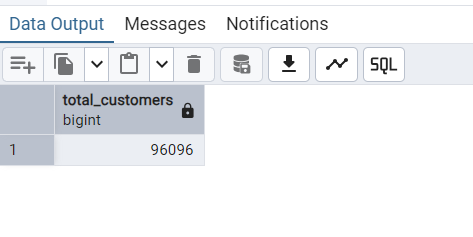

* 2 * What is the total number of orders?
* SELECT COUNT(*) AS total_orders
FROM orders;




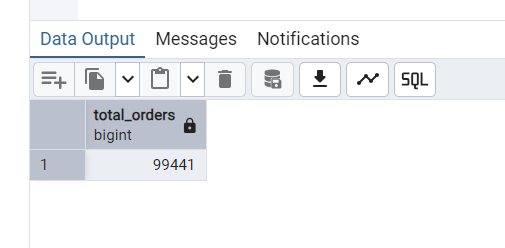

* 3 * How many sellers are registered?
* SELECT COUNT(*) AS total_sellers
FROM sellers;


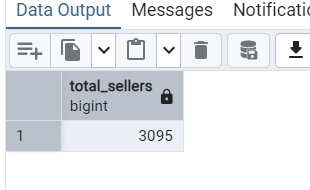

* 4 * How many products are available?
* SELECT COUNT(*) AS total_products
FROM products;




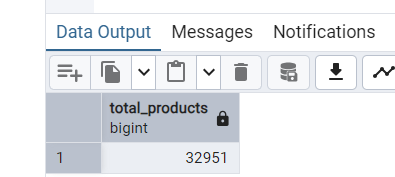

* 5 * What is the total revenue generated?
* SELECT ROUND(SUM(payment_value),2) AS total_revenue
FROM order_payments;


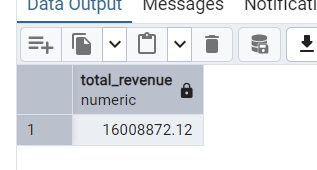

* 6 *  What is the average payment value?

* SELECT ROUND(AVG(payment_value),2) AS average_payment
FROM order_payments;



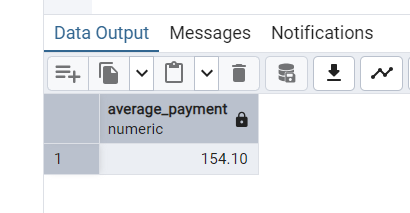

* 7 *  What is the distribution of order statuses?
* SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;



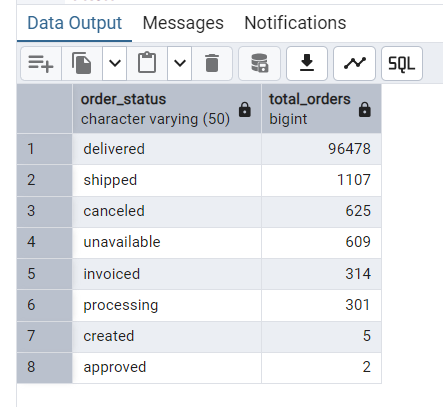

## CUSTOMER ANALYSIS

* 1 * Which states have the highest number of unique customers?
* SELECT
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;


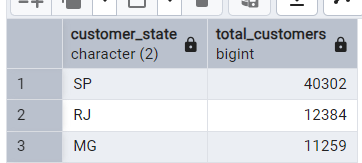

* 2 * Which are the top 10 cities with the highest number of unique customers?
* SELECT
    customer_city,
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS total_customers
FROM customers
GROUP BY customer_city, customer_state
ORDER BY total_customers DESC
LIMIT 10;

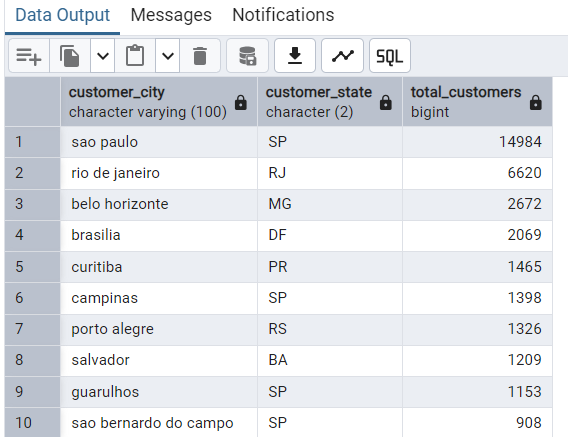

* 3 * How many customers does each state contribute as a percentage of the total customer base?

* SELECT
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS total_customers,
    ROUND(
        COUNT(DISTINCT customer_unique_id) * 100.0 /
        (SELECT COUNT(DISTINCT customer_unique_id) FROM customers),
        2
    ) AS customer_percentage
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;


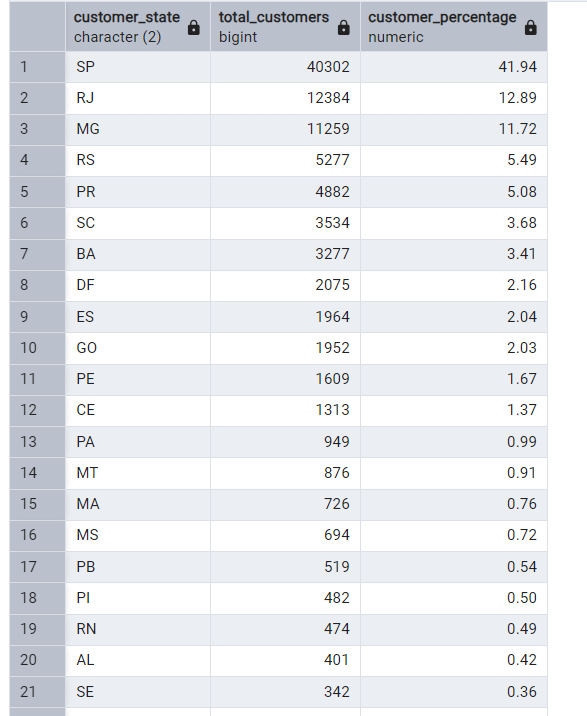   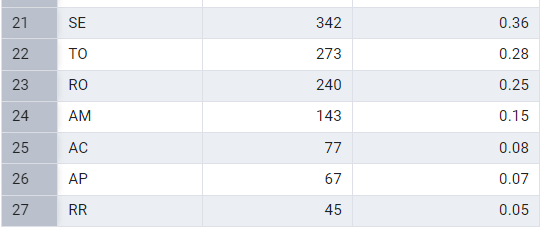

* 4 *  How many new customers were acquired each month?
* SELECT
    DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS acquisition_month,
    COUNT(DISTINCT c.customer_unique_id) AS new_customers
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
ORDER BY acquisition_month;




* 5 * Which customers placed the highest number of orders?

* SELECT
    c.customer_unique_id,
    COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
ORDER BY total_orders DESC;



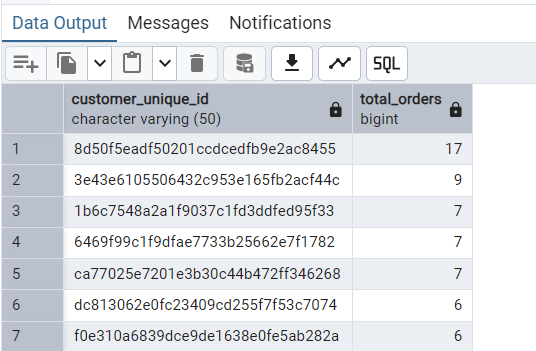

* 6  * What is the average number of orders per unique customer?
* SELECT
    ROUND(
        COUNT(o.order_id)::NUMERIC /
        COUNT(DISTINCT c.customer_unique_id),
        2
    ) AS average_orders_per_customer
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id;




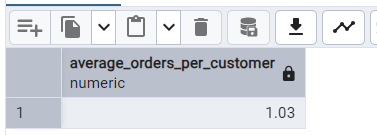    

* 7 * Which states have the highest repeat customers?
* SELECT
    customer_state,
    COUNT(*) AS repeat_customers
FROM (
    SELECT
        c.customer_unique_id,
        c.customer_state,
        COUNT(o.order_id) AS total_orders
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    GROUP BY
        c.customer_unique_id,
        c.customer_state
    HAVING COUNT(o.order_id) > 1
) repeat_customer
GROUP BY customer_state
ORDER BY repeat_customers DESC;



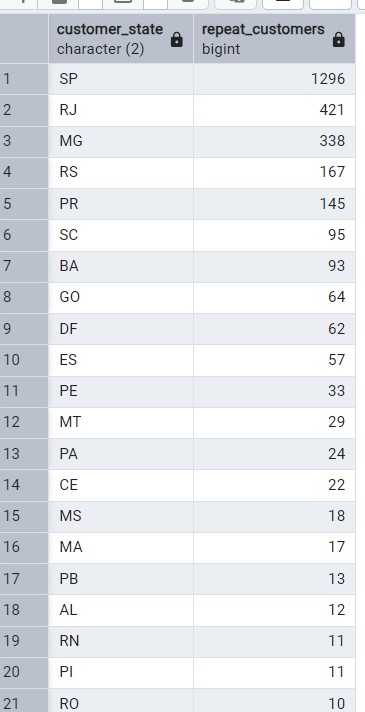    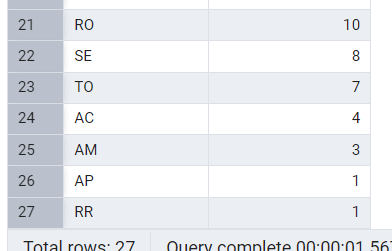

## SALES & REVENUE ANALYSIS

* 1 * What is the monthly revenue trend?

* SELECT
    DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
    ROUND(SUM(op.payment_value), 2) AS monthly_revenue
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY DATE_TRUNC('month', o.order_purchase_timestamp)
ORDER BY month;



* 2 * What is the yearly revenue?

* SELECT
    EXTRACT(YEAR FROM o.order_purchase_timestamp) AS year,
    ROUND(SUM(op.payment_value), 2) AS yearly_revenue
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY year
ORDER BY year;


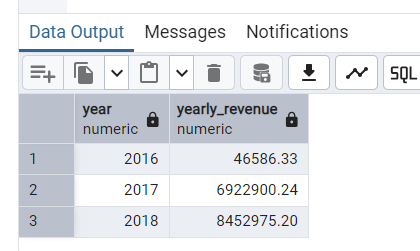

* 3 * Which months generated the highest revenue?
* SELECT
    TO_CHAR(DATE_TRUNC('month', o.order_purchase_timestamp), 'Mon YYYY') AS month,
    ROUND(SUM(op.payment_value), 2) AS revenue
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY DATE_TRUNC('month', o.order_purchase_timestamp)
ORDER BY revenue DESC;



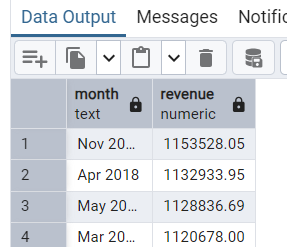

* 4 * What is the Month-over-Month (MoM) revenue growth?

* WITH monthly_revenue AS (
    SELECT
        DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
        SUM(op.payment_value) AS revenue
    FROM orders o
    JOIN order_payments op
        ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY DATE_TRUNC('month', o.order_purchase_timestamp)
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    ROUND(
        LAG(revenue) OVER (ORDER BY month),
        2
    ) AS previous_month_revenue,
    ROUND(
        ((revenue - LAG(revenue) OVER (ORDER BY month))
        / LAG(revenue) OVER (ORDER BY month)) * 100,
        2
    ) AS mom_growth_percentage
FROM monthly_revenue
ORDER BY month;



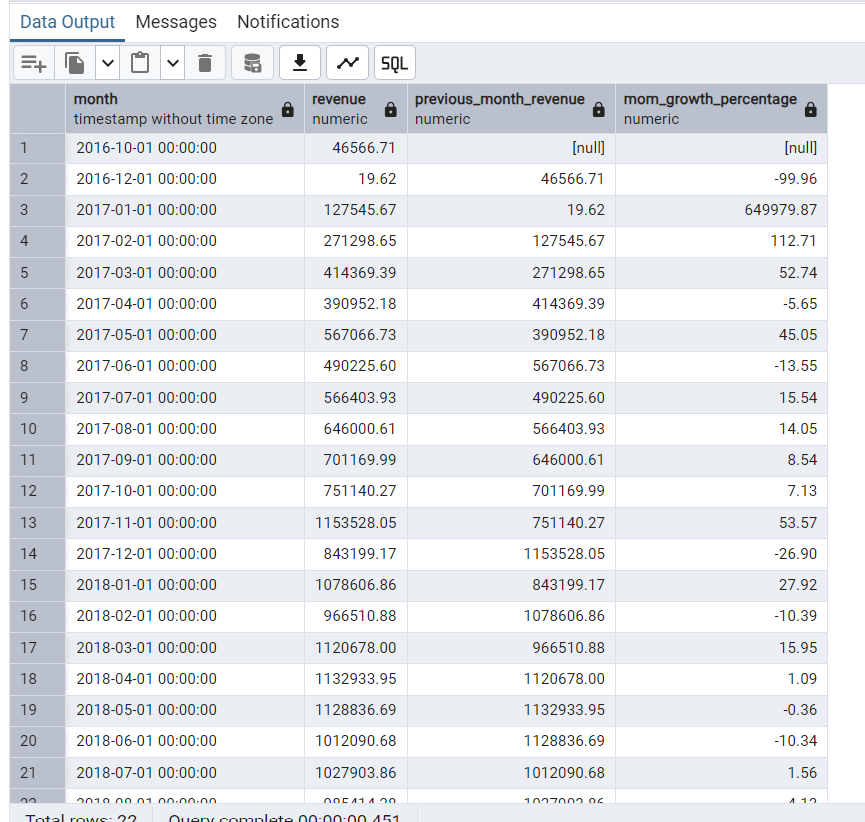  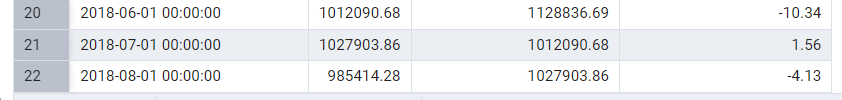


* 5 * What is the Average Order Value (AOV)?
* SELECT
    ROUND(AVG(order_total), 2) AS average_order_value
FROM (
    SELECT
        order_id,
        SUM(payment_value) AS order_total
    FROM order_payments
    GROUP BY order_id
) AS orders_total;



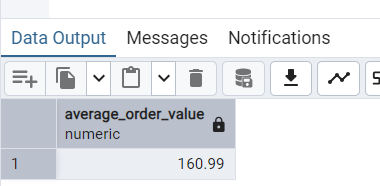

* 6 *  Which are the Top 10 highest revenue-generating orders?
* SELECT
    order_id,
    ROUND(SUM(payment_value), 2) AS order_value
FROM order_payments
GROUP BY order_id
ORDER BY order_value DESC
LIMIT 10;


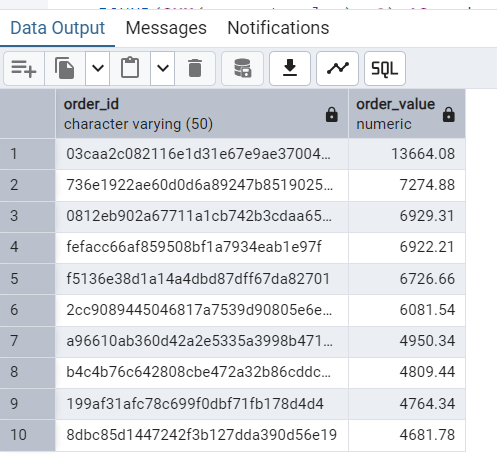

* 7  *   What is the cumulative monthly revenue over time?
* WITH monthly_revenue AS (
    SELECT
        DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
        SUM(op.payment_value) AS revenue
    FROM orders o
    JOIN order_payments op
        ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY DATE_TRUNC('month', o.order_purchase_timestamp)
)

SELECT
    month,
    ROUND(revenue, 2) AS monthly_revenue,
    ROUND(
        SUM(revenue) OVER (
            ORDER BY month
        ),
        2
    ) AS cumulative_revenue
FROM monthly_revenue
ORDER BY month;






* 8 * Which day of the week generates the highest revenue?
* SELECT
    TRIM(TO_CHAR(o.order_purchase_timestamp, 'Day')) AS day_of_week,
    ROUND(SUM(op.payment_value), 2) AS revenue
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY day_of_week,
         EXTRACT(DOW FROM o.order_purchase_timestamp)
ORDER BY EXTRACT(DOW FROM o.order_purchase_timestamp);


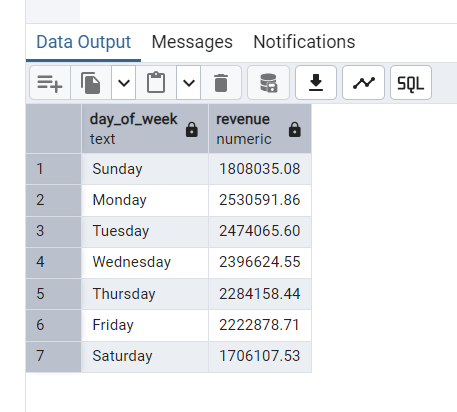

## PRODUCT ANALYSIS

* 1  *  Which product categories generate the highest revenue?
* SELECT
    pct.product_category_name_english AS category,
    ROUND(SUM(op.payment_value), 2) AS total_revenue
FROM orders o
JOIN order_payments op
    ON o.order_id = op.order_id
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY pct.product_category_name_english
ORDER BY total_revenue DESC;


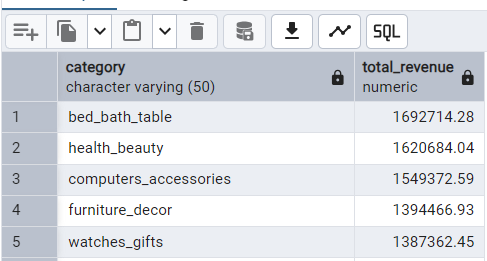

* 2 *  Which are the Top 10 best-selling product categories?
* SELECT
    pct.product_category_name_english AS category,
    COUNT(*) AS products_sold
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
GROUP BY pct.product_category_name_english
ORDER BY products_sold DESC
LIMIT 10;


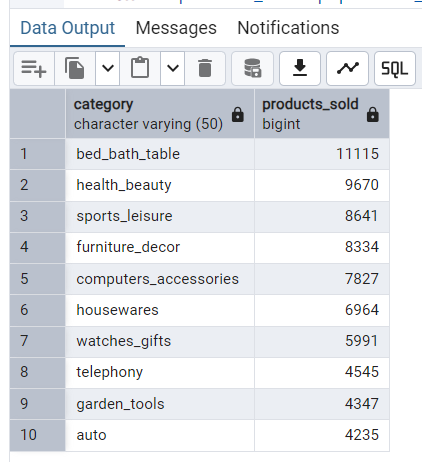

* 3 *  Which individual products generated the highest revenue?
* SELECT
    oi.product_id,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(*) AS units_sold
FROM order_items oi
GROUP BY oi.product_id
ORDER BY total_revenue DESC
LIMIT 10;


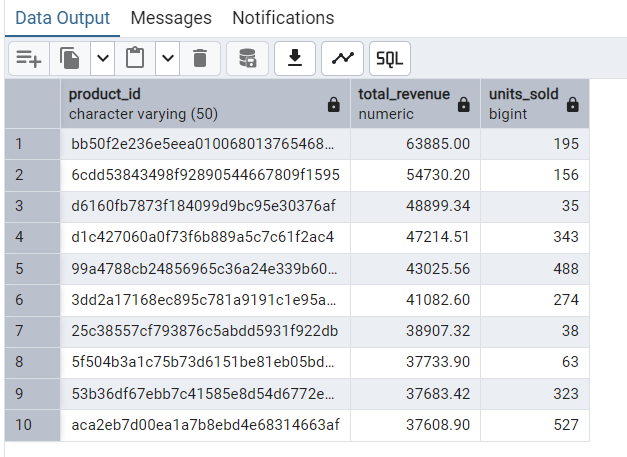

* 4 *  Which products sold the most units?
* SELECT
    oi.product_id,
    COUNT(*) AS units_sold
FROM order_items oi
GROUP BY oi.product_id
ORDER BY units_sold DESC
LIMIT 10;



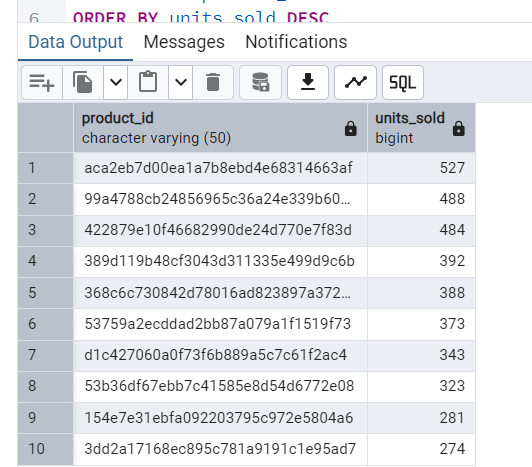

* 5  * What is the average product price by category?
* SELECT
    pct.product_category_name_english AS category,
    ROUND(AVG(oi.price), 2) AS average_price
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
GROUP BY pct.product_category_name_english
ORDER BY average_price DESC;





* 6* Which product categories have the highest average review ratings?


* SELECT
    pct.product_category_name_english AS category,
    ROUND(AVG(orv.review_score), 2) AS average_rating
FROM order_reviews orv
JOIN orders o
    ON orv.order_id = o.order_id
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
GROUP BY pct.product_category_name_english
ORDER BY average_rating DESC;



* 7 *  Which product categories have the highest average delivery cost?

* SELECT
    pct.product_category_name_english AS category,
    ROUND(AVG(oi.freight_value), 2) AS average_freight_cost
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
GROUP BY pct.product_category_name_english
ORDER BY average_freight_cost DESC;



## SELLER ANALYSIS

* !* Which sellers generated the highest revenue?

* SELECT
    s.seller_id,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM sellers s
JOIN order_items oi
    ON s.seller_id = oi.seller_id
JOIN orders o
    ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY s.seller_id
ORDER BY total_revenue DESC
LIMIT 10;



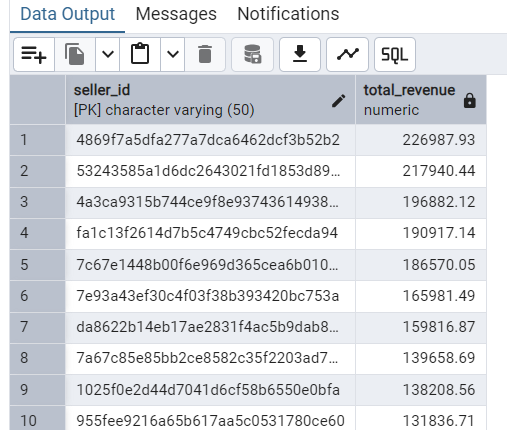

* 2 * Which sellers fulfilled the highest number of orders?
* SELECT
    s.seller_id,
    COUNT(DISTINCT oi.order_id) AS total_orders
FROM sellers s
JOIN order_items oi
    ON s.seller_id = oi.seller_id
GROUP BY s.seller_id
ORDER BY total_orders DESC
LIMIT 10;


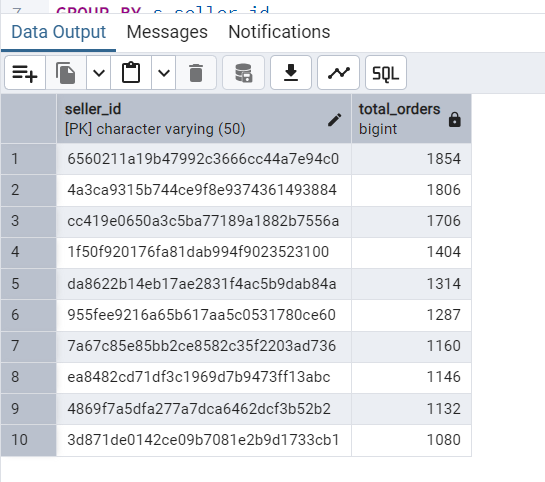

* 3* What is the average revenue generated per seller?

* WITH seller_revenue AS (
    SELECT
        seller_id,
        SUM(price) AS revenue
    FROM order_items
    GROUP BY seller_id
)

SELECT
    ROUND(AVG(revenue), 2) AS average_revenue_per_seller
FROM seller_revenue;


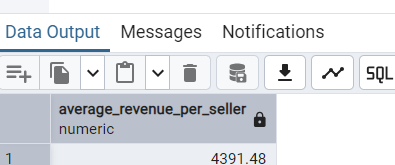

* 4* Which sellers charge the highest average freight cost?

* SELECT
    seller_id,
    ROUND(AVG(freight_value), 2) AS average_freight
FROM order_items
GROUP BY seller_id
ORDER BY average_freight DESC
LIMIT 10;


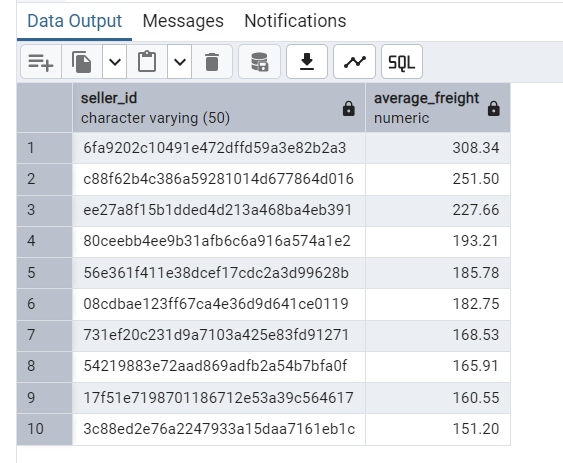

* 5 * Rank sellers based on total revenue.

* WITH seller_revenue AS (
    SELECT
        seller_id,
        SUM(price) AS total_revenue
    FROM order_items
    GROUP BY seller_id
)

SELECT
    seller_id,
    ROUND(total_revenue, 2) AS total_revenue,
    RANK() OVER (
        ORDER BY total_revenue DESC
    ) AS revenue_rank
FROM seller_revenue
ORDER BY revenue_rank;



* 6 * Which sellers sell the widest variety of products?

* SELECT
    seller_id,
    COUNT(DISTINCT product_id) AS unique_products
FROM order_items
GROUP BY seller_id
ORDER BY unique_products DESC
LIMIT 10;



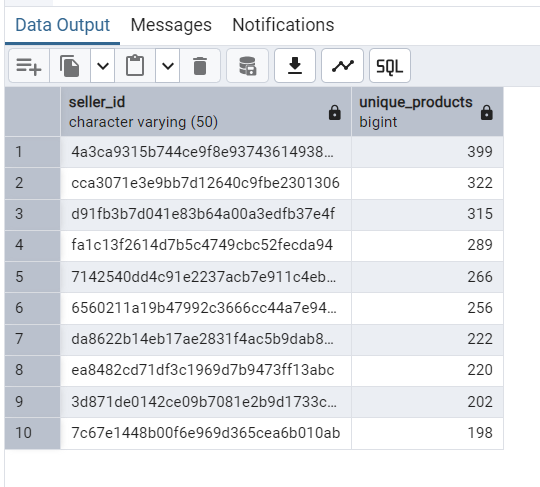

## ORDER & DELIVERY ANALYSIS

* 1 * How many orders were placed each month?

* SELECT
    DATE_TRUNC('month', order_purchase_timestamp) AS month,
    COUNT(order_id) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;




* 2 * What is the distribution of order statuses?

* SELECT
    order_status,
    COUNT(*) AS total_orders,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;




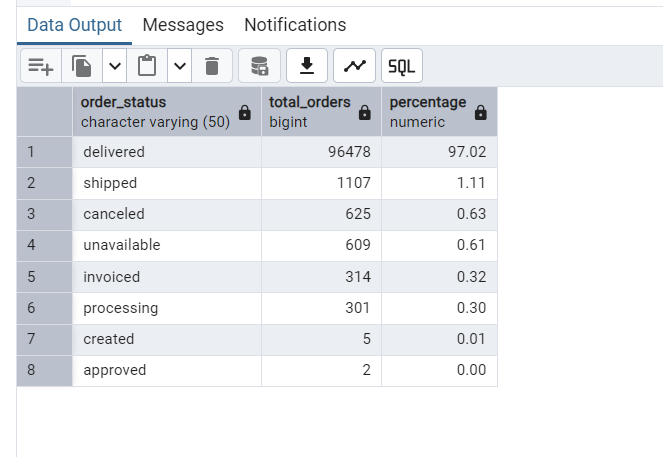

* 3 * What is the average delivery time (in days)?

* SELECT
    ROUND(
        AVG(
            order_delivered_customer_date::date -
            order_purchase_timestamp::date
        ),
        2
    ) AS average_delivery_days
FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL;

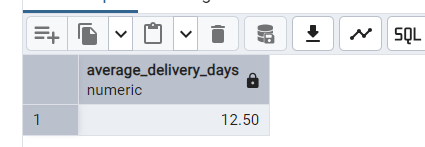

* 4 * What is the average shipping time (Seller → Carrier)?
* 
* SELECT
    ROUND(
        AVG(
            order_delivered_carrier_date::date -
            order_purchase_timestamp::date
        ),
        2
    ) AS average_shipping_days
FROM orders
WHERE order_delivered_carrier_date IS NOT NULL;








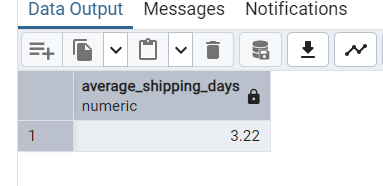

* 5 * Which states experience the longest average delivery time?
* SELECT
    c.customer_state,
    ROUND(
        AVG(
            o.order_delivered_customer_date::date -
            o.order_purchase_timestamp::date
        ),
        2
    ) AS average_delivery_days
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY average_delivery_days DESC;



* 6  * How many orders were delivered late?
* SELECT
    COUNT(*) AS late_orders
FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date > order_estimated_delivery_date;

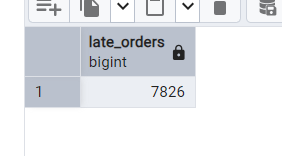

* 7 * What percentage of delivered orders were delivered late?

 * SELECT
    ROUND(
        COUNT(
            CASE
                WHEN order_delivered_customer_date > order_estimated_delivery_date
                THEN 1
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS late_delivery_percentage
FROM orders
WHERE order_status = 'delivered';


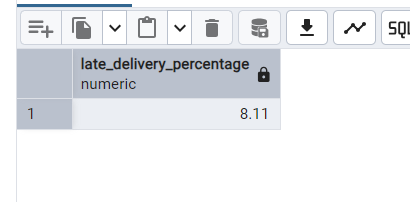

## PAYMENT ANALYSIS

* 1 * Which payment methods are used the most?
* SELECT
    payment_type,
    COUNT(*) AS total_transactions
FROM order_payments
GROUP BY payment_type
ORDER BY total_transactions DESC;

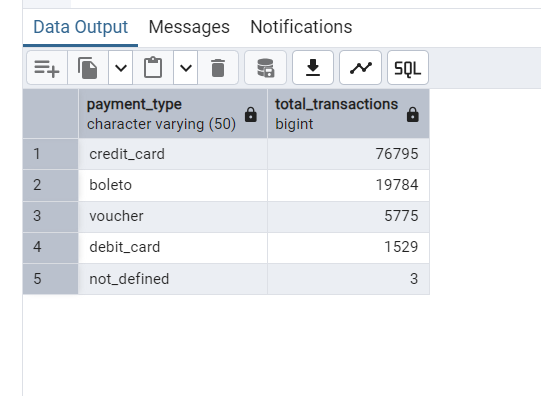

* 2 * How much revenue does each payment method generate?
* 
SELECT
    payment_type,
    ROUND(SUM(payment_value), 2) AS total_revenue
FROM order_payments
GROUP BY payment_type
ORDER BY total_revenue DESC;





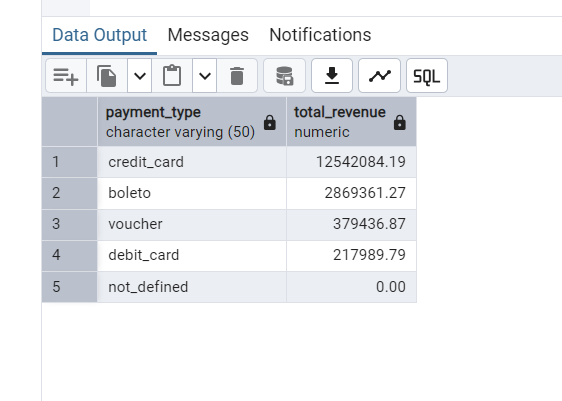

* 3 * What is the average payment amount for each payment method?
* SELECT
    payment_type,
    ROUND(AVG(payment_value), 2) AS average_payment
FROM order_payments
GROUP BY payment_type
ORDER BY average_payment DESC;



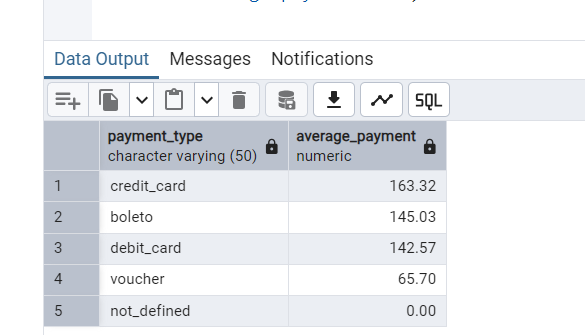

* 4 * How many customers choose installment payments?

* SELECT
    CASE
        WHEN payment_installments = 1 THEN 'Single Payment'
        ELSE 'Installments'
    END AS payment_mode,
    COUNT(*) AS total_transactions,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM order_payments
GROUP BY payment_mode
ORDER BY total_transactions DESC;



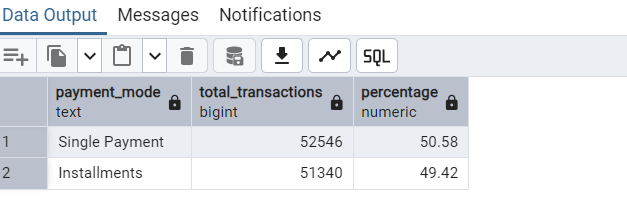

## CUSTOMER REVIEW ANALYSIS


* 1* Which product categories receive the highest and lowest customer ratings?

* SELECT
    pct.product_category_name_english AS category,
    ROUND(AVG(orv.review_score), 2) AS average_rating,
    COUNT(DISTINCT orv.review_id) AS total_reviews
FROM order_reviews orv
JOIN orders o
    ON orv.order_id = o.order_id
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
GROUP BY pct.product_category_name_english
HAVING COUNT(DISTINCT orv.review_id) >= 20
ORDER BY average_rating DESC;






* 2* Does delivery time impact customer satisfaction?

* SELECT
    review_score,
    ROUND(
        AVG(
            o.order_delivered_customer_date::date -
            o.order_purchase_timestamp::date
        ),
        2
    ) AS average_delivery_days,
    COUNT(*) AS total_orders
FROM order_reviews orv
JOIN orders o
    ON orv.order_id = o.order_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY review_score
ORDER BY review_score DESC;



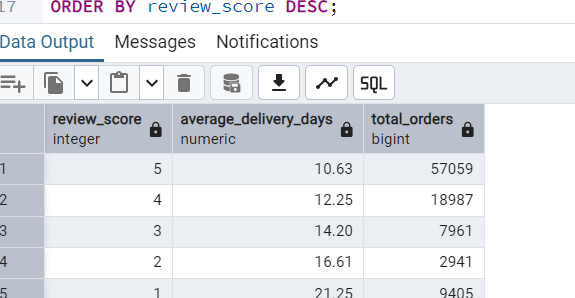

## GEOGRAPHIC ANALYSIS


* 1* Which states generate the highest revenue?

* SELECT
    c.customer_state,
    ROUND(SUM(op.payment_value), 2) AS total_revenue
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_payments op
    ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_revenue DESC;





* 2 * Which states place the highest number of orders?
* SELECT
    c.customer_state,
    COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC;




* 3 * Which states have the highest average order value (AOV)?
* WITH order_value AS (
    SELECT
        order_id,
        SUM(payment_value) AS total_order_value
    FROM order_payments
    GROUP BY order_id
)

SELECT
    c.customer_state,
    ROUND(AVG(ov.total_order_value), 2) AS average_order_value
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_value ov
    ON o.order_id = ov.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY average_order_value DESC;





* 4* Which states have the longest average delivery time?
* SELECT
    c.customer_state,
    ROUND(
        AVG(
            o.order_delivered_customer_date::date -
            o.order_purchase_timestamp::date
        ),
        2
    ) AS average_delivery_days
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY average_delivery_days DESC;